# **House price predictor**

Building a house price predictor from scratch involves implementing Multiple Linear Regression. We will model the relationship between our independent variables (features) and the dependent variable (price) using the Ordinary Least Squares (OLS) method.


### ***1. Mathematical foundation***

The ModelWe represent the predicted house price $\hat{y}$ as a linear combination of input features $x_i$:

$$\hat{y} = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n$$

$\hat{y}$ is our predicted price

w0 is our intial price

wj is the weight of each feature. Location and size of the house don't have the same effect on a house price


In [2]:
#importing important libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


### Loading California Housing Data

In [3]:
#import the data and check if it works
california_housing_df = pd.read_csv('/content/sample_data/california_housing_train.csv')
display(california_housing_df.head())

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


In [4]:
california_housing_df.shape

(17000, 9)

## 1. Mathematical Foundation for Multiple Linear Regression

### The Model
In Multiple Linear Regression, we model the relationship between a dependent variable $y$ (house price) and a set of independent features $x_1, x_2, \dots, x_n$. The hypothesis function is defined as:

$$h_w(x) = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n$$

To simplify calculations, we express this in **Vectorized Form**. By defining $x_0 = 1$ (the bias term), the input vector is $x = [1, x_1, x_2, \dots, x_n]^T$ and the weight vector is $w = [w_0, w_1, w_2, \dots, w_n]^T$:

$$\hat{y} = Xw$$

Where:
*   $X$ is the **Design Matrix** of size $m \times (n+1)$ (where $m$ is the number of training examples).
*   $w$ is the **Parameter Vector** of size $(n+1) \times 1$.

### The Cost Function (Mean Squared Error)
To evaluate the performance of our model, we use the **Mean Squared Error (MSE)** cost function. It measures the average squared difference between the predicted values and the actual values:

$$J(w) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_w(x^{(i)}) - y^{(i)} \right)^2$$

### Optimization: Batch Gradient Descent
We minimize the cost function $J(w)$ by iteratively updating the weights. The update rule for each parameter $w_j$ is:

$$w_j := w_j - \alpha \frac{\partial}{\partial w_j} J(w)$$

The partial derivative (gradient) for the $j^{th}$ weight is calculated as:

$$\frac{\partial J(w)}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} \left( h_w(x^{(i)}) - y^{(i)} \right) x_j^{(i)}$$

In **Matrix Form**, the gradient update for the entire vector $w$ is:

$$w := w - \frac{\alpha}{m} X^T (Xw - y)$$

Where:
*   $\alpha$ is the **Learning Rate**, a hyperparameter that controls the step size.
*   $X^T (Xw - y)$ is the gradient vector pointing in the direction of steepest increase.

# Step 2: Data exploration

Here we are going to explore what we have in the data like median income, average
house age, average rooms and bedrooms per household,
population, household count, and the target variable—median
house value.



In [5]:
#Median income
data=display(california_housing_df['median_income'].describe())
data

,median_income
count,17000.000000
mean,3.883578
std,1.908157
min,0.499900
25%,2.566375
50%,3.544600
75%,4.767000
max,15.000100


In [6]:
#Median income
median_incomeC= california_housing_df['median_income'].mean()
print(f"The average income in california is: {median_incomeC:.2f} ten thousand USD")

The average income in california is: 3.88 ten thousand USD


In [7]:
#Average house age
average_house_age = california_housing_df['housing_median_age'].mean()
print(f"The average house age is: {average_house_age:.2f} years")

The average house age is: 28.59 years


In [8]:
#Average number of rooms per household
average_rooms = california_housing_df['total_rooms'].mean()
average_households= california_housing_df['households'].mean()
print(f"The average number of rooms per household is: {average_rooms/average_households:.2f} rooms")

The average number of rooms per household is: 5.27 rooms


In [9]:
#Average number of bed rooms per household
average_bedrooms = california_housing_df['total_bedrooms'].mean()
average_households= california_housing_df['households'].mean()
print(f"The average number of bed rooms per household is: {average_bedrooms/average_households:.2f} rooms")

The average number of bed rooms per household is: 1.08 rooms


In [10]:
#Total population
popul= california_housing_df['population'].sum()
print(f"The total number of people in california state is: {popul:.2f}")

The total number of people in california state is: 24302757.00


In [11]:
#Total household
total_households= california_housing_df['households'].sum()
print(f"The total number of households in california state is: {total_households:.2f}")

The total number of households in california state is: 8520773.00


In [12]:
#Target average house value
average_housevalue= california_housing_df['median_house_value'].mean()
print(f"The average value of a house in california state is: {average_housevalue:.2f}")

The average value of a house in california state is: 207300.91


### Step 3: Visualizing Feature Distributions (Histograms)
Exploratory Data Analysis (EDA) involved visualizing
feature distributions and relationships with the target variable.
Histograms, scatter plots, and box plots helped identify the
range and variability of data. This step is critical in
understanding the underlying structure and spotting potential
outliers or anomalies.

Histograms help us understand the distribution of each numerical feature. They can reveal skewness, outliers, and the general spread of the data.

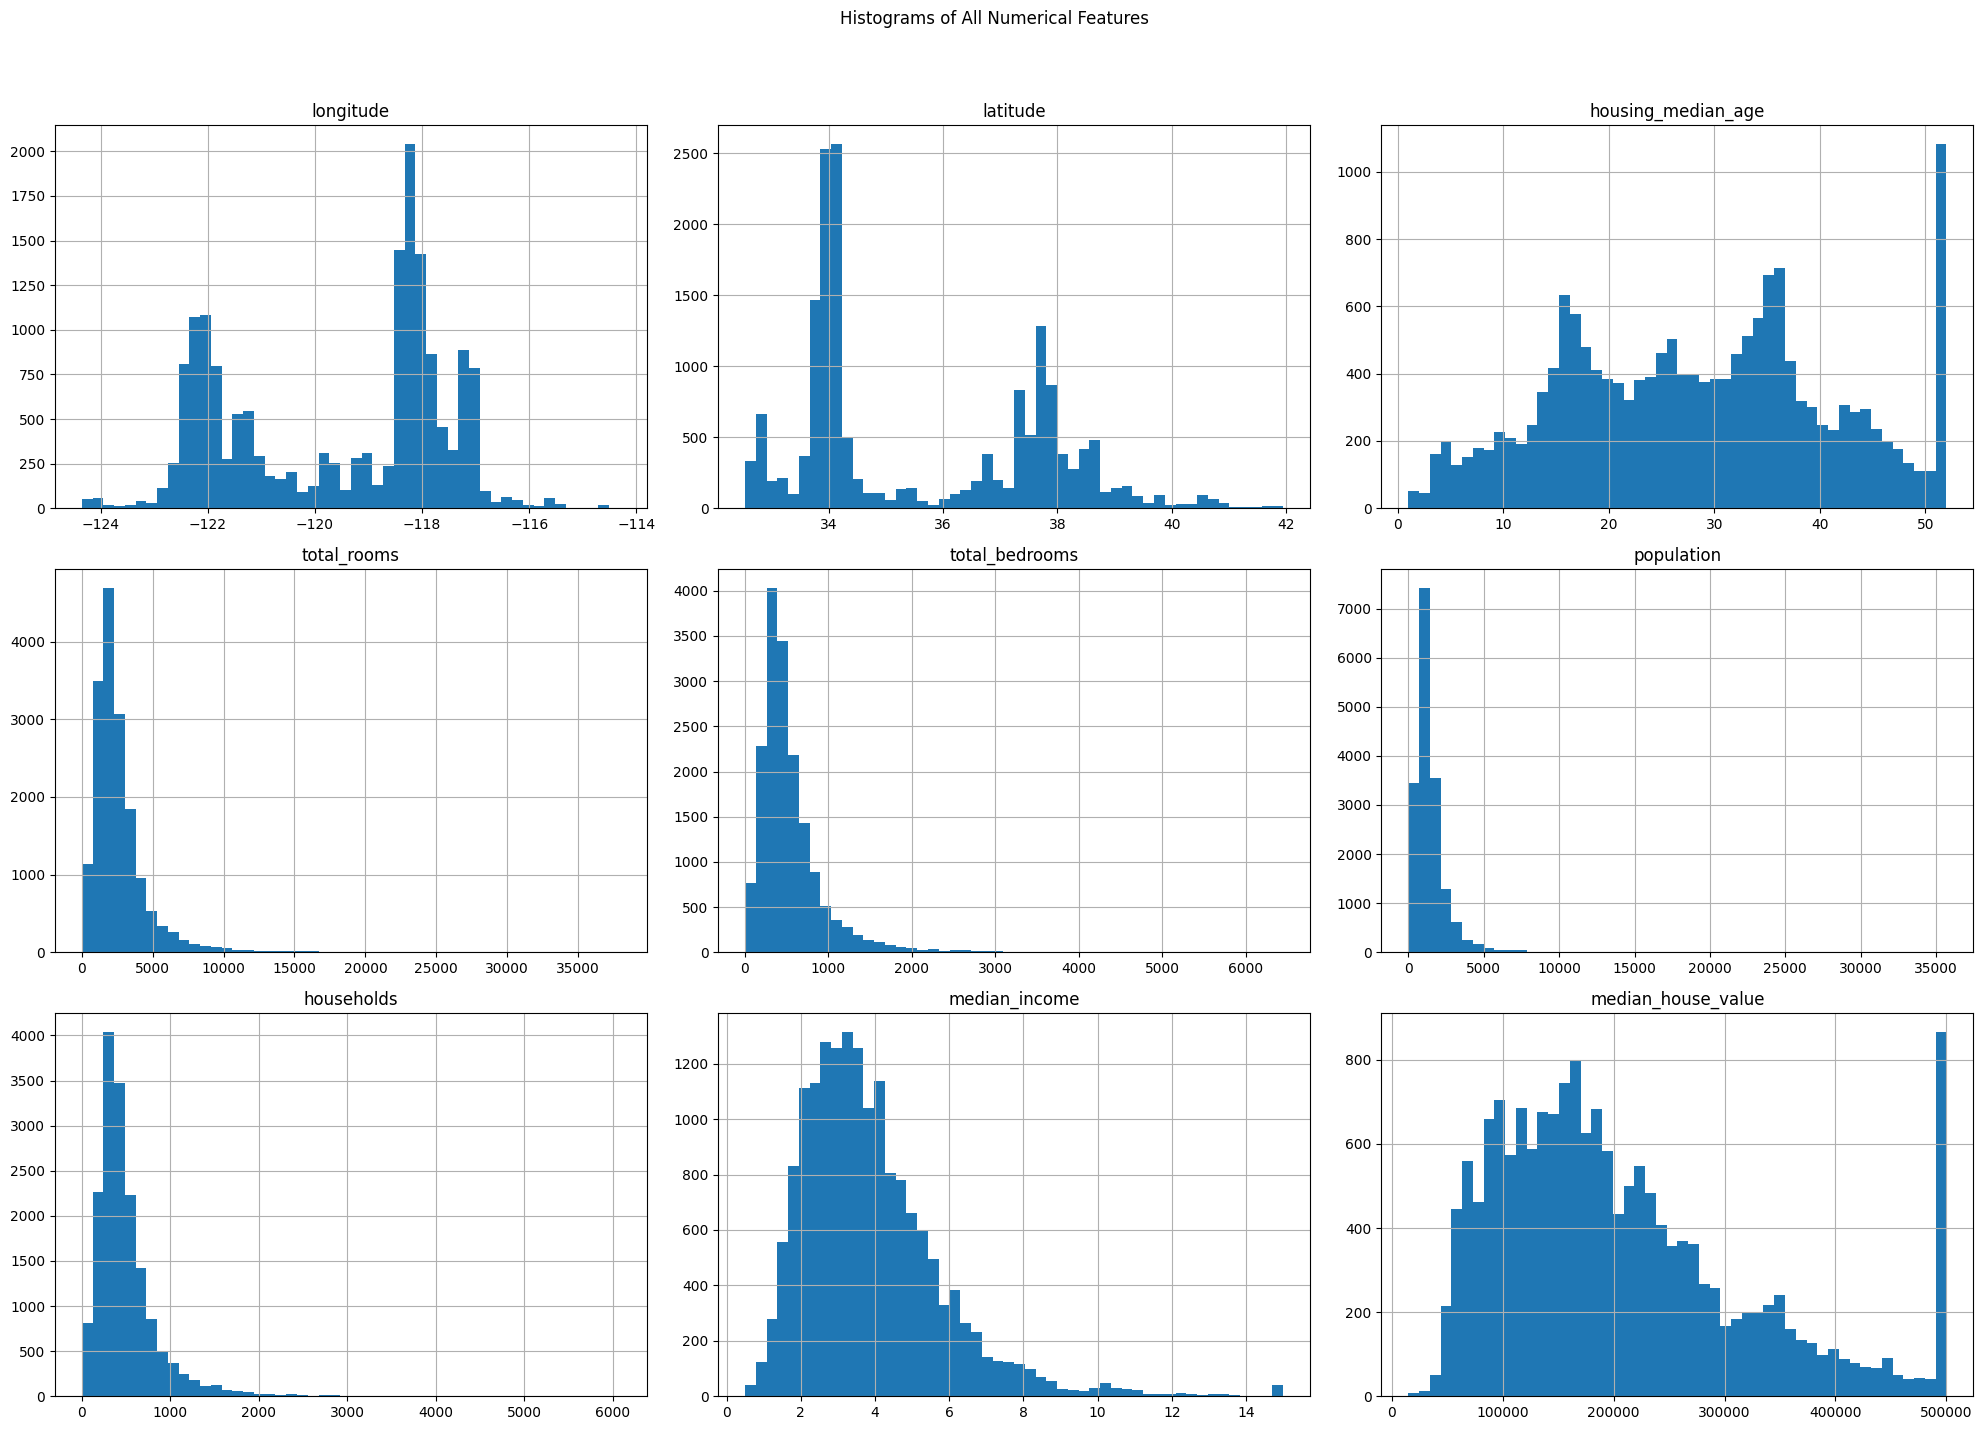

In [13]:
california_housing_df.hist(bins=50, figsize=(20, 15))
plt.suptitle('Histograms of All Numerical Features before scaling')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Visualizing Relationships with the Target Variable (Scatter Plots)

Scatter plots are useful for observing the relationship between individual features and the `median_house_value`.

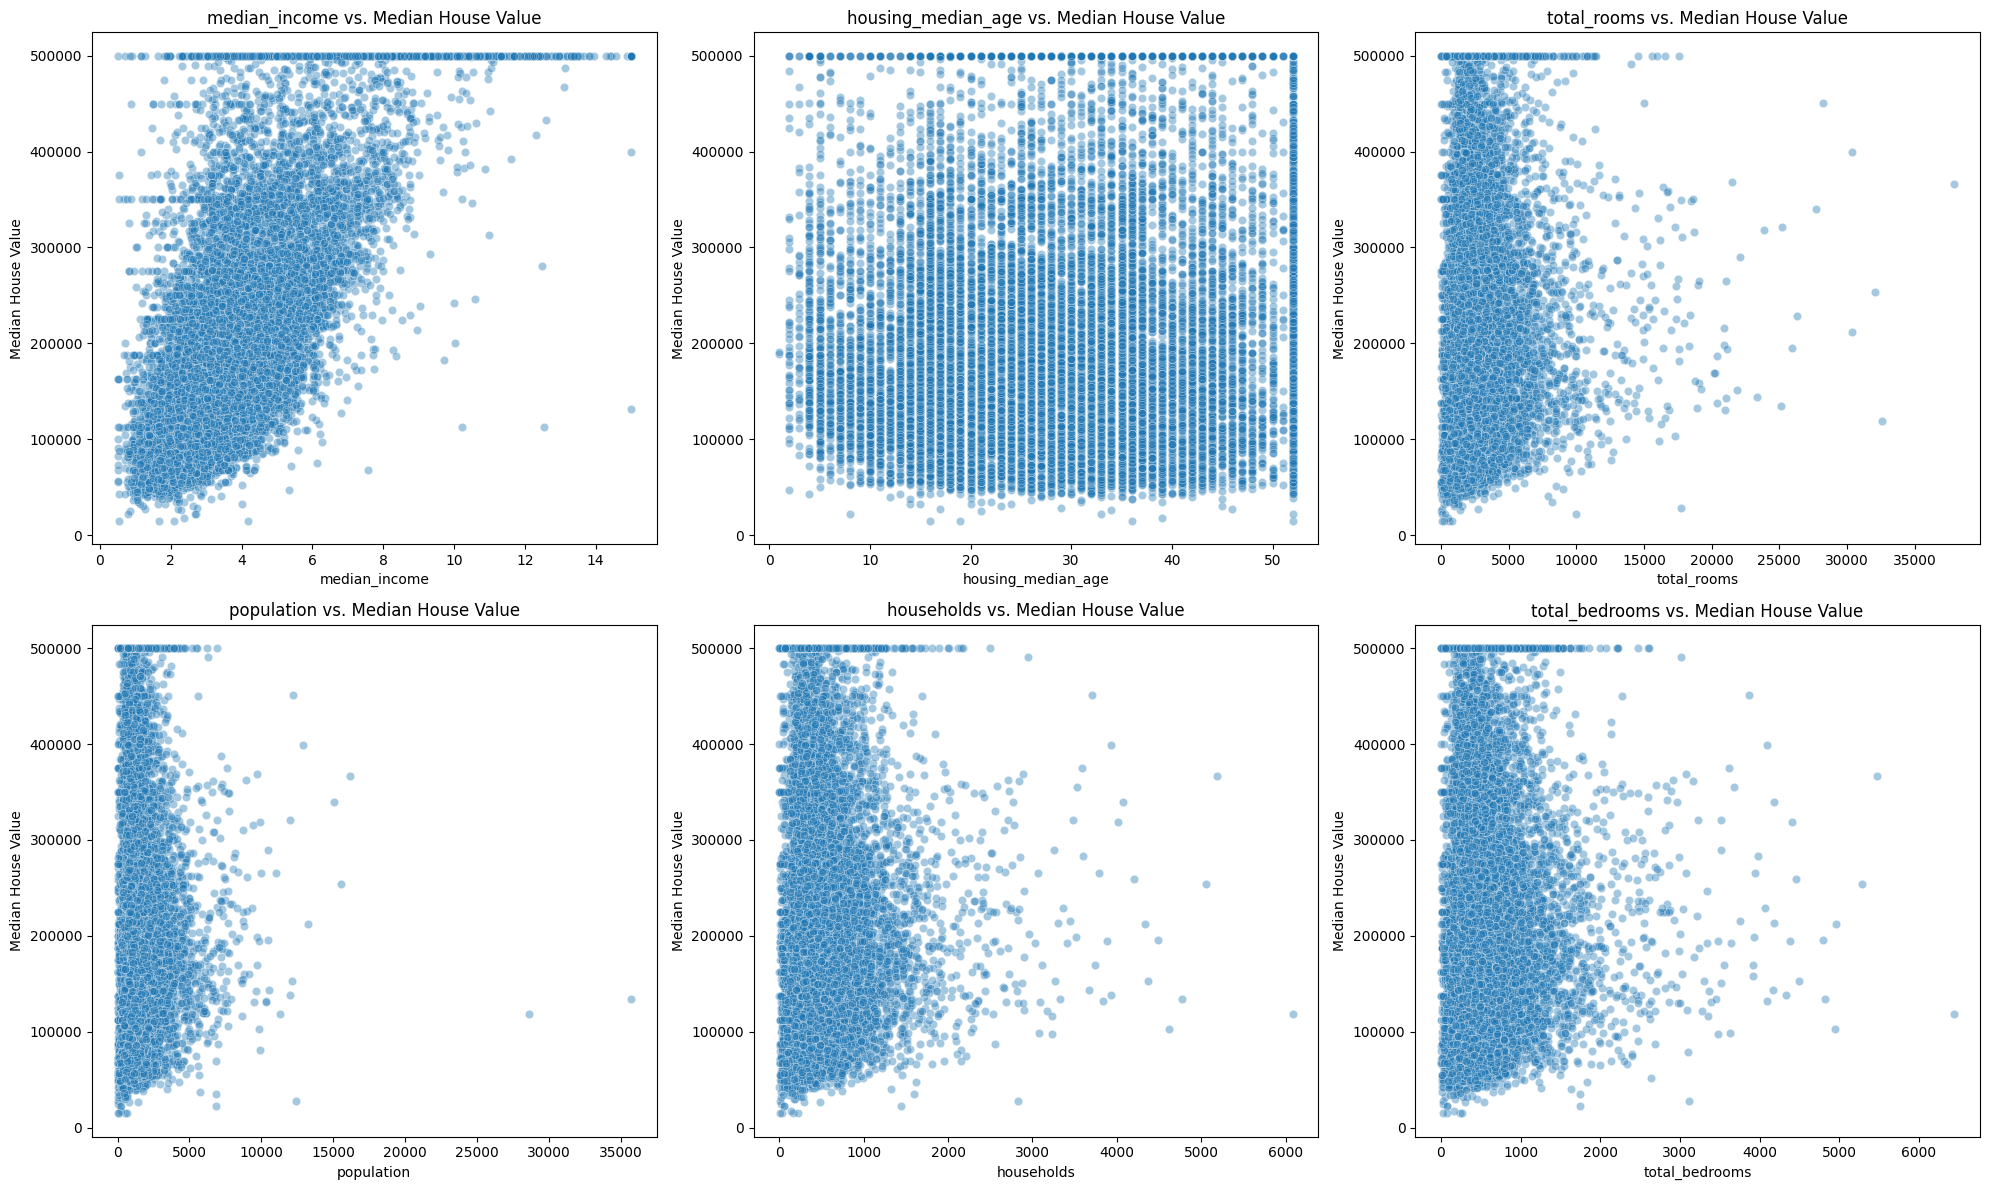

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(20, 12))
axes = axes.flatten()

features_to_plot = ['median_income', 'housing_median_age', 'total_rooms', 'population', 'households', 'total_bedrooms']

for i, feature in enumerate(features_to_plot):
    sns.scatterplot(x=feature, y='median_house_value', data=california_housing_df, ax=axes[i], alpha=0.4)
    axes[i].set_title(f'{feature} vs. Median House Value')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Median House Value')

plt.tight_layout()
plt.show()

### Step 4: Data Preprocessing
Here we categorize the features based on their data types (integer, float, or object) and count the number of features in each category.
**bold text**

In [15]:
feature_types = california_housing_df.dtypes.value_counts()
print("Feature types and their counts:")
print(feature_types)

Feature types and their counts:
float64    9
Name: count, dtype: int64


### Step 5: Data Cleaning and Handling Missing Values
Although the California Housing Dataset is generally
clean, a formal check for missing or inconsistent data should be
performed using .isnull() and summary statistics. Since the
dataset had no missing values, no imputation was necessary.
However, in real-world applications, missing data treatment
such as mean or median imputation, or advanced methods like
K-Nearest Neighbors imputation, should be considered to
maintain data integrity

In [16]:
print(california_housing_df.isnull().values.any())

False


### Step 6: Feature Engineering and Transformation
Feature engineering is crucial for improving model
performance by creating meaningful input variables. Initially,
raw features will be standardized to ensure comparability and
reduce bias in models sensitive to scale (e.g., Linear
Regression). The StandardScaler from Scikit-learn will be
applied to transform features to zero mean and unit variance.
Normalization is particularly important for variables
such as median income and population, which have different
units and magnitudes. Features with skewed distributions
will be log-transformed to reduce skewness and approximate
normality, which benefits models that assume linearity or
normal residuals.
Additionally, interaction terms will be tested, such as
multiplying median income by house age, to capture complex
relationships that individual features alone may not express.

In [18]:
# Standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_array = scaler.fit_transform(california_housing_df)

df_scaled = pd.DataFrame(scaled_array, columns=california_housing_df.columns)

print("\n--- Standardized Features (First 3 Rows) ---")
print(df_scaled.head(3))



--- Standardized Features (First 3 Rows) ---
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0   2.619365 -0.671520           -1.079671     1.361695        1.764204   
1   2.539569 -0.573264           -0.761872     2.296608        3.230441   
2   2.494683 -0.905463           -0.920772    -0.882462       -0.866956   

   population  households  median_income  median_house_value  
0   -0.361184   -0.075998      -1.252543           -1.210558  
1   -0.261865   -0.099404      -1.081483           -1.096745  
2   -0.955354   -0.999252      -1.170105           -1.048461  


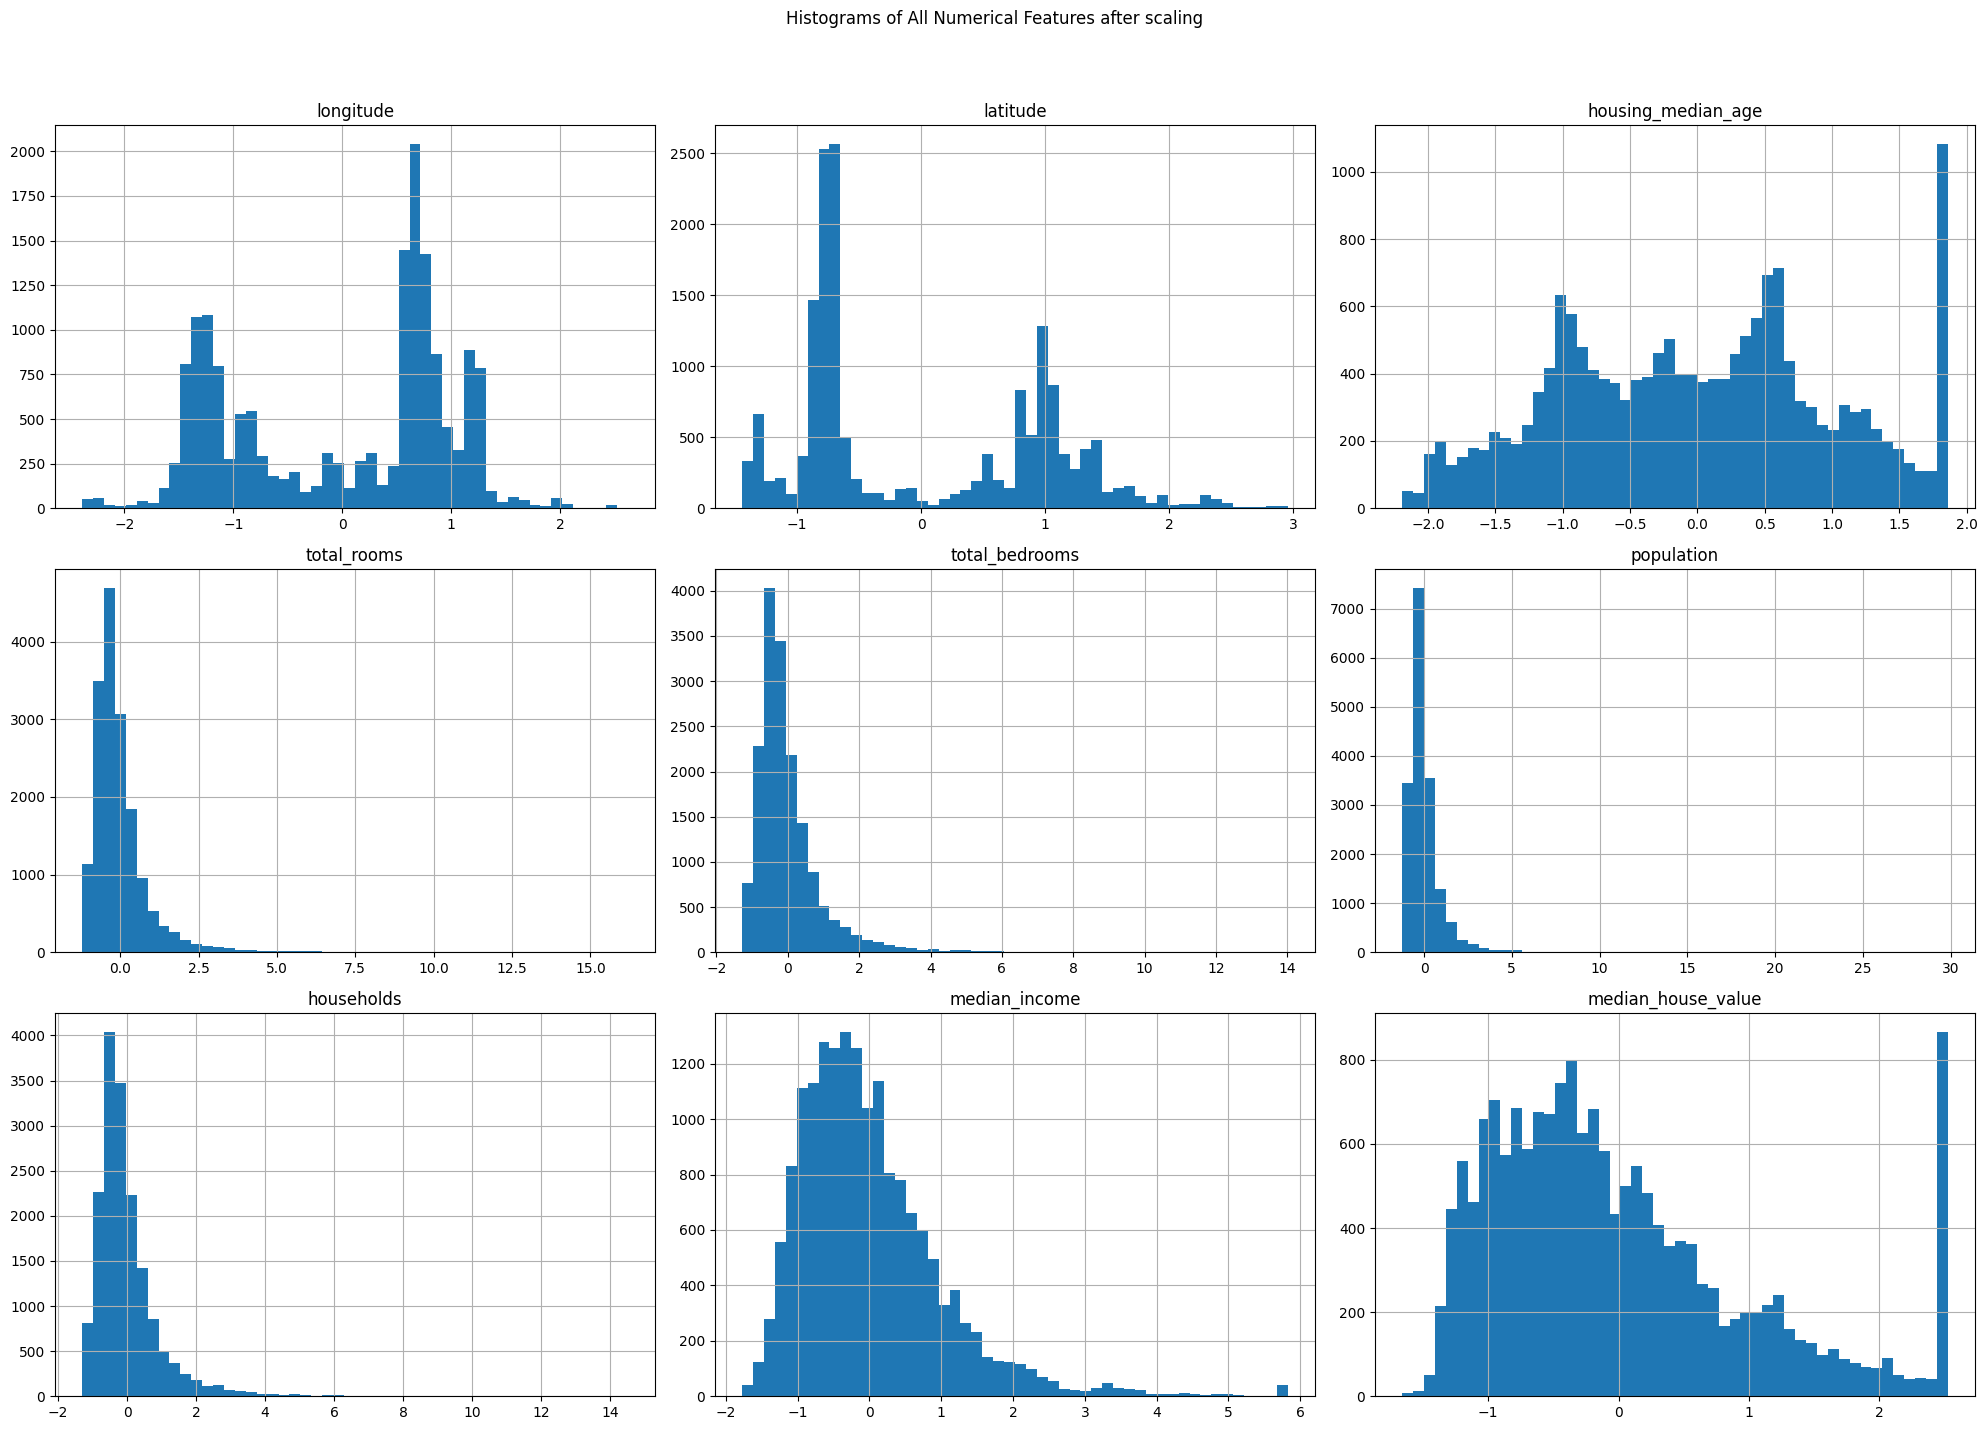

In [19]:
df_scaled.hist(bins=50, figsize=(20, 15))
plt.suptitle('Histograms of All Numerical Features after scaling')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [21]:
#Normalization
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
normalized_array = scaler.fit_transform(california_housing_df)

df_normalized = pd.DataFrame(normalized_array, columns=california_housing_df.columns)

print("\n--- Normalized Features (First 3 Rows) ---")
print(df_normalized.head(3))


--- Normalized Features (First 3 Rows) ---
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0   1.000000  0.175345            0.274510     0.147885        0.198945   
1   0.984064  0.197662            0.352941     0.201608        0.294848   
2   0.975100  0.122210            0.313725     0.018927        0.026847   

   population  households  median_income  median_house_value  
0    0.028364    0.077454       0.068530            0.107012  
1    0.031559    0.075974       0.091040            0.134228  
2    0.009249    0.019076       0.079378            0.145775  


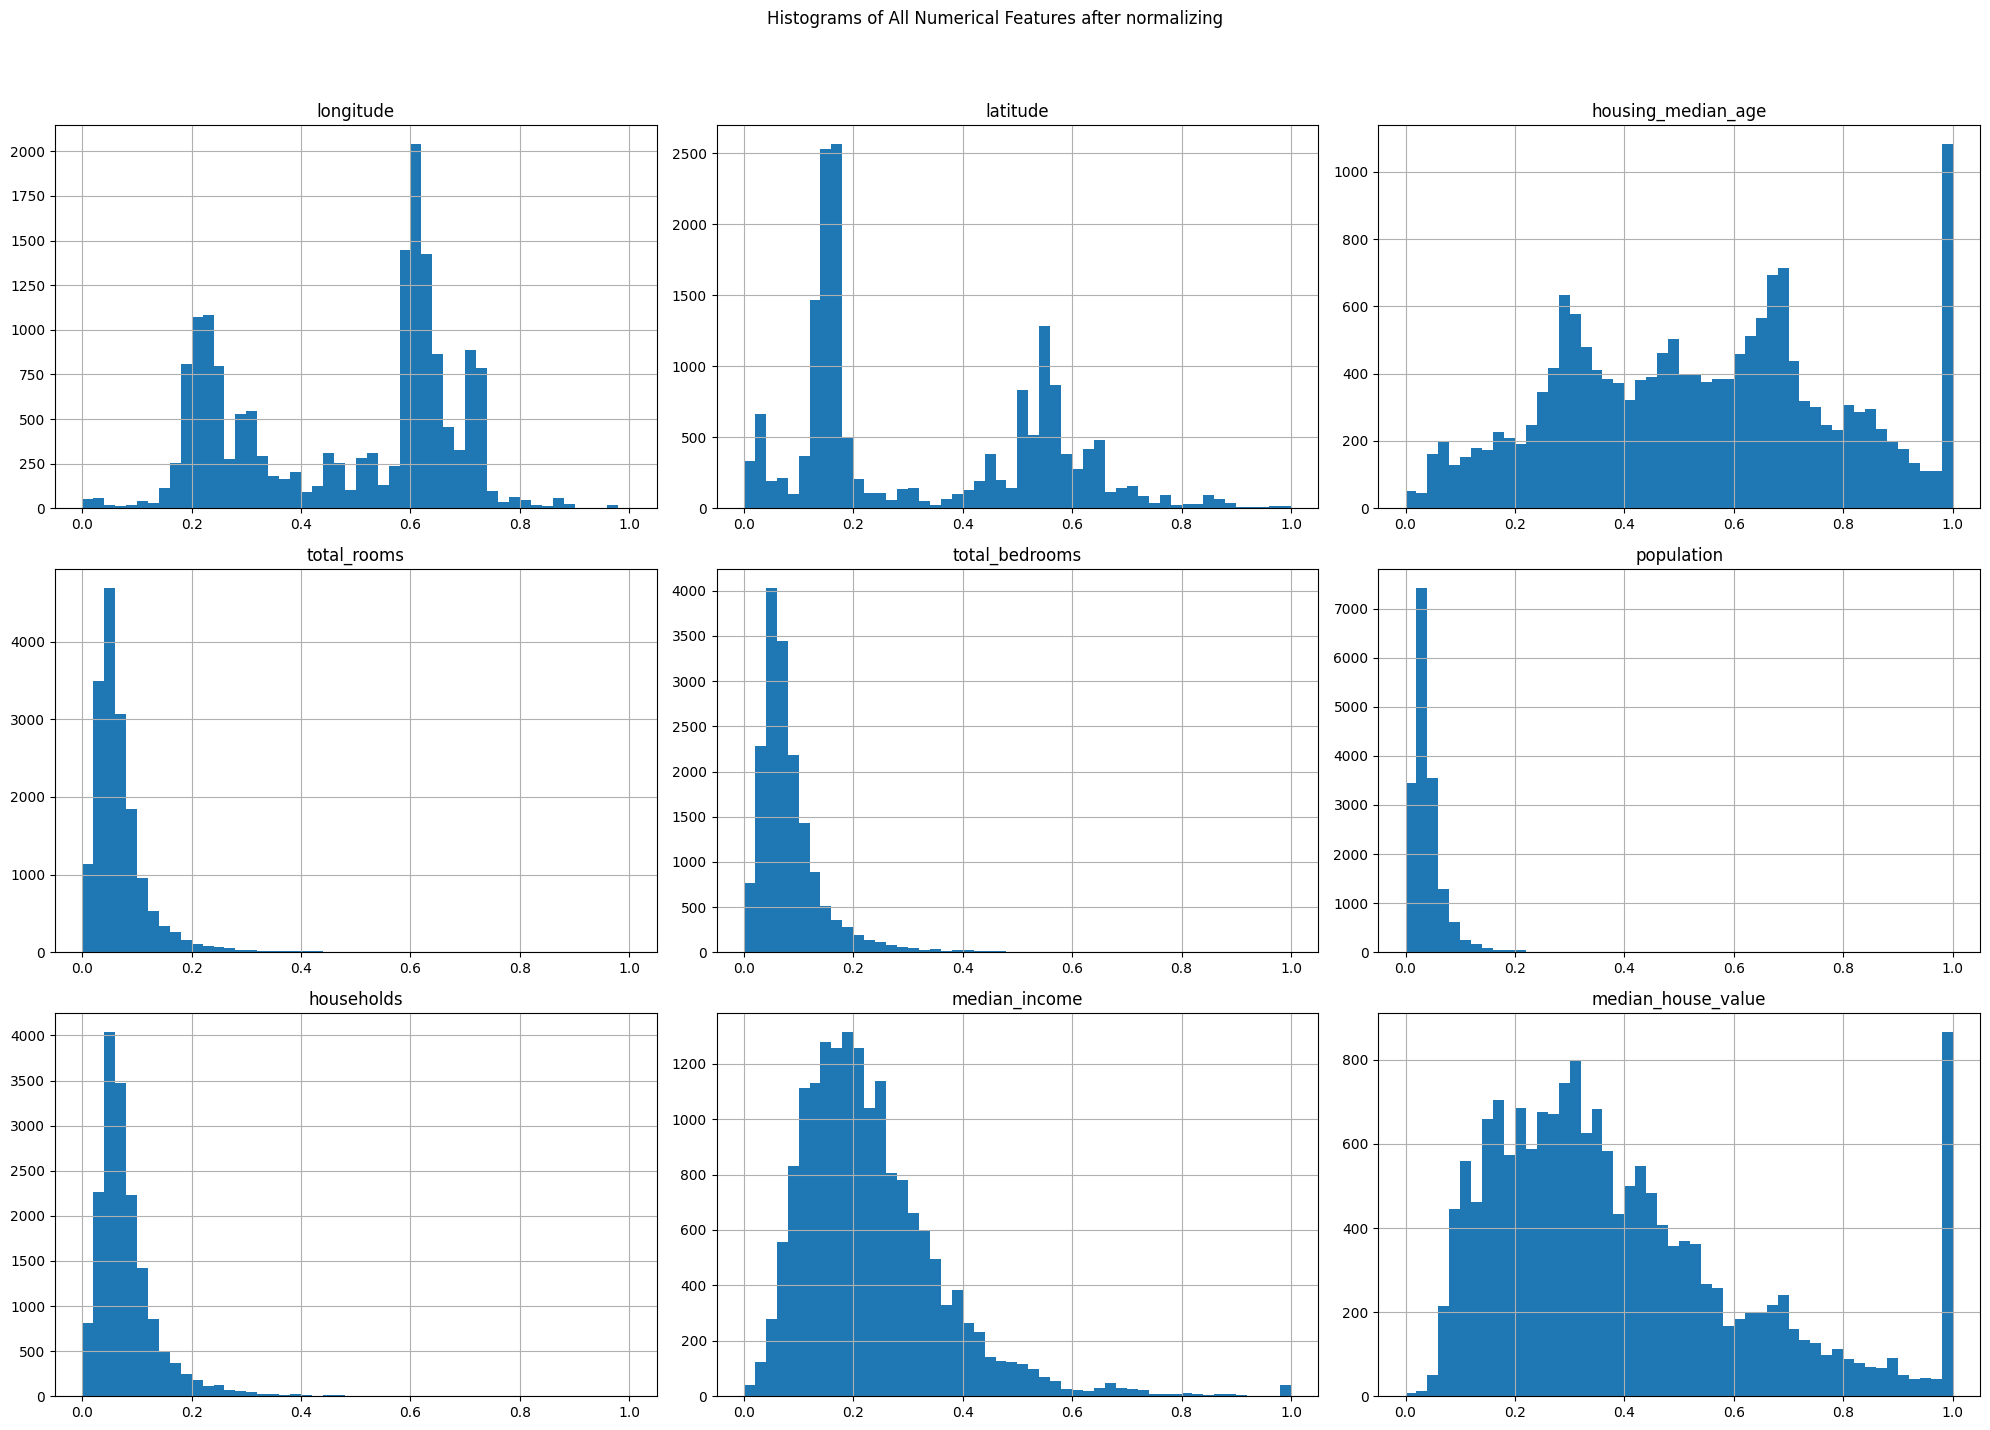

In [23]:
df_normalized.hist(bins=50, figsize=(20, 15))
plt.suptitle('Histograms of All Numerical Features after normalizing')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Step 7: Feature Selection and Correlation Analysis
To minimize redundancy and multicollinearity, Pearson
correlation coefficients among features will be computed and
visualized using a heatmap. Features exhibiting very high
correlation (>0.85) are candidates for removal or
combination to prevent overfitting and inflated variance in
Linear Regression coefficients.
For example, total rooms and total bedrooms show a
strong positive correlation, so the ratio of rooms to bedrooms
will also created as a new feature to provide additional insight
into housing quality.
Recursive Feature Elimination (RFE) will be applied with
cross-validation to select the most impactful features for
Random Forest and XGBoost models. This automated method
systematically removes less important features based on model feedback, improving both interpretability and
performance.

In [24]:
corr_matrix = california_housing_df.corr(method='pearson')

print("--- Pearson Correlation Matrix ---")
print(corr_matrix.round(2))

--- Pearson Correlation Matrix ---
                    longitude  latitude  housing_median_age  total_rooms  \
longitude                1.00     -0.93               -0.11         0.05   
latitude                -0.93      1.00                0.02        -0.04   
housing_median_age      -0.11      0.02                1.00        -0.36   
total_rooms              0.05     -0.04               -0.36         1.00   
total_bedrooms           0.07     -0.07               -0.32         0.93   
population               0.10     -0.11               -0.30         0.86   
households               0.06     -0.07               -0.30         0.92   
median_income           -0.02     -0.08               -0.12         0.20   
median_house_value      -0.04     -0.14                0.11         0.13   

                    total_bedrooms  population  households  median_income  \
longitude                     0.07        0.10        0.06          -0.02   
latitude                     -0.07       -0.11    

In [25]:
# Unstack the matrix into a long-form series and drop self-correlations (where r >=0.85)
corr_pairs = corr_matrix.unstack()
strong_pairs = corr_pairs[(abs(corr_pairs) > 0.5) & (corr_pairs <= 0.85)]

print("\n--- Strong Correlation Pairs (|r| > 0.5) ---")
print(strong_pairs)


--- Strong Correlation Pairs (|r| > 0.5) ---
longitude           latitude             -0.925208
latitude            longitude            -0.925208
median_income       median_house_value    0.691871
median_house_value  median_income         0.691871
dtype: float64


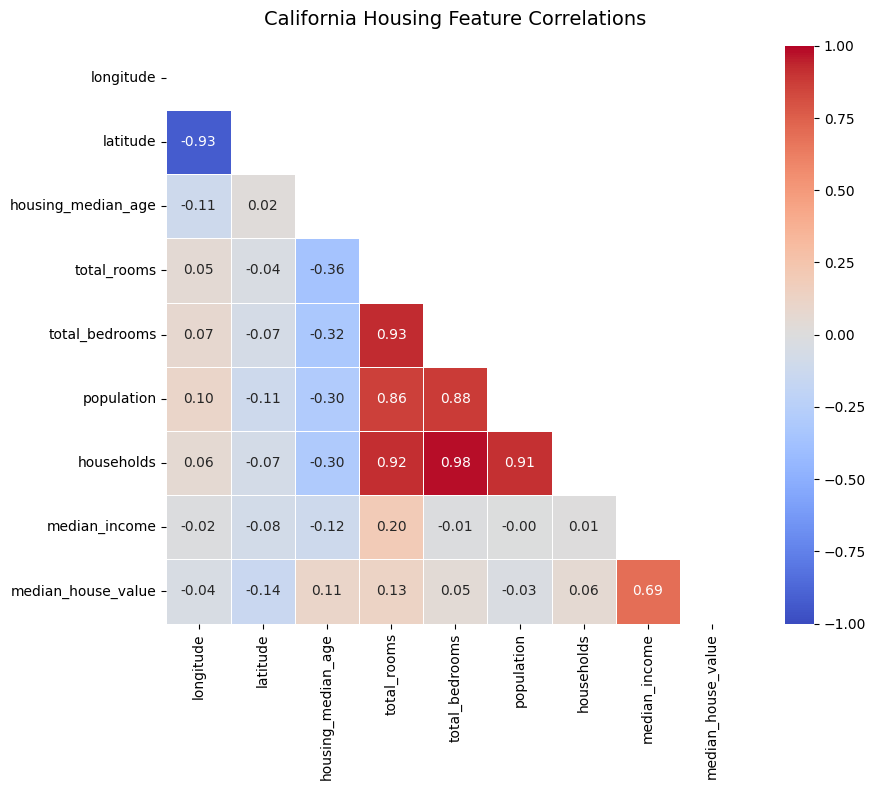

In [28]:
import numpy as np

# 1. Load data and generate the numeric Pearson matrix
df = california_housing_df
corr_matrix = df.corr()

# 2. Setup the chart layout canvas
plt.figure(figsize=(10, 8))

# 3. Create a boolean mask to hide the redundant upper triangle (optional but clean)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# 4. Generate the heatmap graphic configuration
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
)

# 5. Render and display the plot window
plt.title("California Housing Feature Correlations", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

In [32]:
from sklearn.feature_selection import RFECV
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold

# 1. Load the dataset
df = california_housing_df
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

# 2. Define a core estimator that provides feature importances (coef_ or feature_importances_)
# Ridge regression handles collinearity well during elimination
estimator = Ridge()

# 3. Setup cross-validation strategy (e.g., 5-fold CV)
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

# 4. Initialize RFECV
# step=1 drops exactly 1 feature per iteration loop
rfecv = RFECV(
    estimator=estimator,
    step=1,
    cv=cv_strategy,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
)

# 5. Fit the selector to the data
rfecv.fit(X, y)

# 6. Extract results
print(f"Optimal number of features found: {rfecv.n_features_}")

# Create a summary DataFrame of feature rankings
feature_ranking = pd.DataFrame(
    {"Feature": X.columns, "Selected": rfecv.support_, "Rank": rfecv.ranking_}
).sort_values(by="Rank")

print("\n--- Feature Selection Rankings ---")
print(feature_ranking.to_string(index=False))

Optimal number of features found: 8

--- Feature Selection Rankings ---
           Feature  Selected  Rank
         longitude      True     1
          latitude      True     1
housing_median_age      True     1
       total_rooms      True     1
    total_bedrooms      True     1
        population      True     1
        households      True     1
     median_income      True     1


In [33]:
# Drops the unselected columns from your dataframe
X_optimal = rfecv.transform(X)

# Convert back to a DataFrame with column names if needed
optimal_columns = X.columns[rfecv.support_]
df_optimal = pd.DataFrame(X_optimal, columns=optimal_columns)


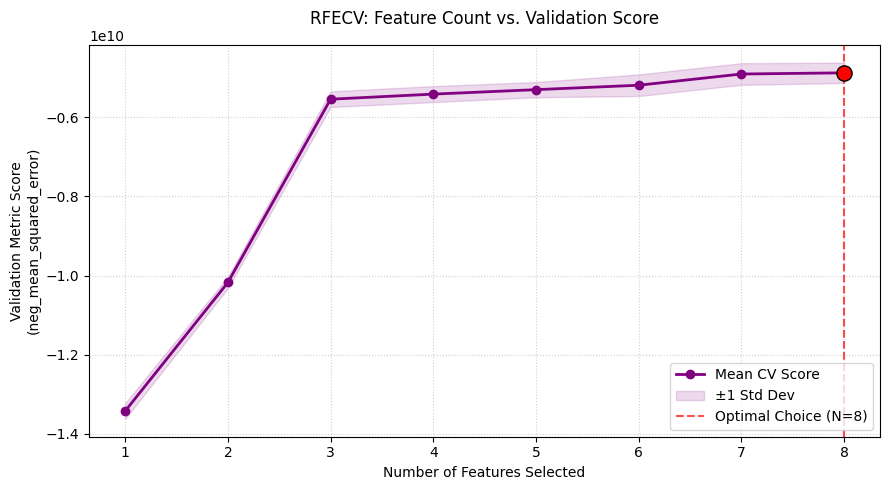

In [34]:
# 1. Retrieve cross-validation scores from the trained RFECV object
# Scikit-Learn 1.0+ uses cv_results_['mean_test_score']
if hasattr(rfecv, "cv_results_"):
    # Convert negative MSE back to positive MSE if desired, or plot as is
    mean_scores = rfecv.cv_results_["mean_test_score"]
    # If you want to plot standard deviation bands:
    std_scores = rfecv.cv_results_["std_test_score"]
else:
    # Legacy fallback for older scikit-learn versions
    mean_scores = rfecv.grid_scores_
    std_scores = np.zeros_like(mean_scores)

# 2. Define the x-axis (number of features evaluated)
num_features = np.arange(1, len(mean_scores) + 1)

# 3. Initialize the plot layout canvas
plt.figure(figsize=(9, 5))

# 4. Plot the mean CV performance line
plt.plot(
    num_features,
    mean_scores,
    marker="o",
    color="purple",
    linewidth=2,
    label="Mean CV Score",
)

# 5. Fill the standard deviation variance bounds (optional but highly informative)
if std_scores.any():
    plt.fill_between(
        num_features,
        mean_scores - std_scores,
        mean_scores + std_scores,
        color="purple",
        alpha=0.15,
        label="±1 Std Dev",
    )

# 6. Highlight the mathematical optimal selection peak
optimal_count = rfecv.n_features_
optimal_score = mean_scores[optimal_count - 1]

plt.axvline(
    x=optimal_count,
    color="red",
    linestyle="--",
    alpha=0.7,
    label=f"Optimal Choice (N={optimal_count})",
)
plt.scatter(
    optimal_count,
    optimal_score,
    color="red",
    s=120,
    zorder=5,
    edgecolors="black",
)

# 7. Configure axis strings and grid lines
plt.title("RFECV: Feature Count vs. Validation Score", fontsize=12, pad=15)
plt.xlabel("Number of Features Selected", fontsize=10)
plt.ylabel(
    "Validation Metric Score\n(neg_mean_squared_error)", fontsize=10
)  # Update this string if you change your scoring metric
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower right")

# 8. Render and display graphic window
plt.tight_layout()
plt.show()


### Step 8: Model Building & Mathematical view
## 1) Linear Regression
This is one of the oldest and simplest ways to predict a
number. In my case, it’s used to guess the house price based
on things like the number of rooms, average income, or
location. The formula looks like this:
$$\hat{y} = w_0 + w_1x_1 + w_2x_2 + \dots + w_nx_n$$

In this formula, ŷ is the predicted price, the w_n are weights
or coefficients, and the xs are the input features. Linear
regression is easy to use and understand but doesn’t work well
when the data doesn’t follow a straight-line pattern.

## 2) Random Forest
This model is based on decision trees. Instead of using just one tree, it creates a “forest” of many trees and then averages their results to get a better prediction. Each tree is built from a random sample of the data, which helps avoid overfitting. The formula used is:
$$\hat{y} = \frac{1}{T} \sum_{i=1}^{T} h_i(x)$$
Here, $T$ is the total number of trees, and $h_i(x)$ means the prediction from each tree. Random Forest is good at dealing with messy, complex data and can still give accurate predictions.

## 3) XGBoost (Extreme Gradient Boosting)
XGBoost is a newer and more advanced method that builds models one step at a time. Each new model focuses on fixing the mistakes made by the last one. Over time, this helps the final prediction become more accurate. The formula used is:
$$\hat{y}^{(t)}_i = \hat{y}^{(t-1)}_i + \eta \cdot f_t(x_i)$$
Where $\eta$ is the learning rate, and $f_t(x_i)$ is the new tree added in the current round. XGBoost is powerful because it includes regularization, which helps it avoid overfitting and gives better results with complex data.

### Step 9: Training and Hyperparameter Tuning
The dataset was split into training and testing sets using an
80/20 ratio, ensuring that the test set was unseen during
training to provide an unbiased evaluation of model
performance.
Hyperparameter tuning was conducted using Grid Search
with 5-fold cross-validation on the training data. This
approach systematically tests combinations of parameters to
find the optimal set that maximizes the cross-validated R²
score.
For example, Random Forest tuning explored values of
n_estimators between 100 and 500, max_depth from 5 to 50,
and min_samples_leaf between 1 and 5. XGBoost parameters such as eta were tuned from 0.01 to 0.3, with tree depths
ranging from 3 to 10, and regularization terms adjusted to
mitigate overfitting.
Early stopping rounds were used in XGBoost training to
halt model building when validation performance ceased
improving, thus saving computational time and avoiding
unnecessary complexity.

In [35]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Assuming df_optimal (features selected by RFECV) and y (target) are available from previous steps
# If df_optimal is not defined, use the full feature set X from earlier RFECV cell
# For consistency, I will use X and y which were already defined in the RFECV cell.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Linear Regression Model Training

We start with a simple Linear Regression model as a baseline. While it doesn't involve complex hyperparameter tuning, fitting and evaluating it provides a foundational performance metric.

In [36]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
mse_lr = mean_squared_error(y_test, y_pred_lr)

print(f"Linear Regression R² Score: {r2_lr:.4f}")
print(f"Linear Regression MSE: {mse_lr:.2f}")

Linear Regression R² Score: 0.6636
Linear Regression MSE: 4634658406.22


### Random Forest Regressor Training and Hyperparameter Tuning

For the Random Forest model, we will perform Grid Search Cross-Validation to find the optimal combination of `n_estimators`, `max_depth`, and `min_samples_leaf` that maximizes the R² score.

In [38]:
rf_model = RandomForestRegressor(random_state=42)

param_grid_rf = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [10, 20, 30],      # Maximum depth of the tree
    'min_samples_leaf': [1, 2, 4]   # Minimum number of samples required to be at a leaf node
}

grid_search_rf = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid_rf,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search_rf.fit(X_train, y_train)

print(f"Best parameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Best R² score from Grid Search (Random Forest): {grid_search_rf.best_score_:.4f}")

best_rf_model = grid_search_rf.best_estimator_
y_pred_rf = best_rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)

print(f"Random Forest R² Score on Test Set: {r2_rf:.4f}")
print(f"Random Forest MSE on Test Set: {mse_rf:.2f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Random Forest: {'max_depth': 30, 'min_samples_leaf': 2, 'n_estimators': 300}
Best R² score from Grid Search (Random Forest): 0.8173
Random Forest R² Score on Test Set: 0.8252
Random Forest MSE on Test Set: 2408291929.26


### XGBoost Regressor Training and Hyperparameter Tuning

For XGBoost, we'll also use Grid Search Cross-Validation to tune parameters like `n_estimators`, `max_depth`, `learning_rate` (eta), and `subsample`. Early stopping rounds will be implicitly handled by XGBoost during training if a validation set is used, but for `GridSearchCV`, the cross-validation itself helps prevent overfitting.

In [39]:
xgb_model = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)

param_grid_xgb = {
    'n_estimators': [100, 200, 300], # Number of boosting rounds
    'max_depth': [3, 5, 7],         # Maximum depth of a tree
    'learning_rate': [0.05, 0.1, 0.2], # Step size shrinkage to prevent overfitting
    'subsample': [0.7, 0.9]         # Subsample ratio of the training instance
}

grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=2
)

grid_search_xgb.fit(X_train, y_train)

print(f"Best parameters for XGBoost: {grid_search_xgb.best_params_}")
print(f"Best R² score from Grid Search (XGBoost): {grid_search_xgb.best_score_:.4f}")

best_xgb_model = grid_search_xgb.best_estimator_
y_pred_xgb = best_xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)

print(f"XGBoost R² Score on Test Set: {r2_xgb:.4f}")
print(f"XGBoost MSE on Test Set: {mse_xgb:.2f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Best parameters for XGBoost: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.9}
Best R² score from Grid Search (XGBoost): 0.8364
XGBoost R² Score on Test Set: 0.8448
XGBoost MSE on Test Set: 2138953816.85


### Step 10: RESULTS AND EVALUATION

#### A. System Specifications
This project was conducted on a MacBook Air, equipped with a 1.1 GHz dual-core Intel Core i3 processor and 8 GB of RAM, along with Intel Iris Plus graphics. All code was developed and executed within a Jupyter Notebook environment.

#### Dataset Details
For this project, the California Housing Dataset from Scikit-learn was utilized. This dataset comprises various features such as median income, housing median age, total rooms, and population per block, and is a standard benchmark for regression tasks.

#### B. Evaluation Metrics
To evaluate and compare the performance of the models, the following metrics were used:
*   **R² Score**: Indicates the proportion of variance in the dependent variable that can be predicted from the independent variables. A higher R² score suggests a better fit.
*   **RMSE (Root Mean Squared Error)**: Represents the square root of the average of the squared differences between predicted and actual values. It provides a measure of the magnitude of the errors, with lower values indicating better model accuracy.
*   **MSE (Mean Squared Error)**: The average of the squared errors. Like RMSE, lower values indicate better model performance, but it's more sensitive to large errors due to squaring.
*   **MAE (Mean Absolute Error)**: The average of the absolute differences between predicted and actual values. It provides a more robust measure of error as it is less sensitive to outliers compared to MSE or RMSE.


--- Model Evaluation Results ---


,Model,R2 Score,MSE,RMSE,MAE
0,Linear Regression,0.6636,4.634658e+09,68078.3255,49983.4747
1,Random Forest,0.8252,2.408292e+09,49074.3510,32033.4981
2,XGBoost,0.8448,2.138954e+09,46248.8250,30212.6406


/tmp/ipykernel_6529/3237378850.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='R2 Score', data=results, palette='viridis')


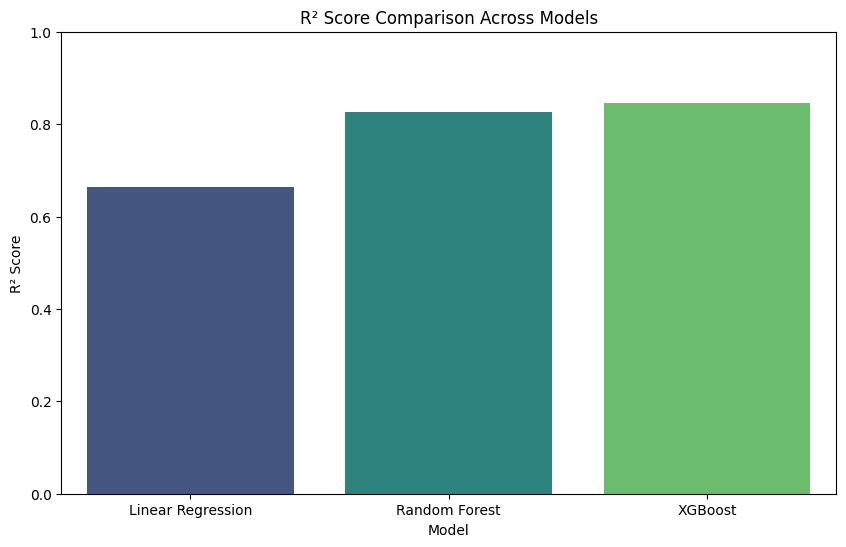

In [42]:
from sklearn.metrics import mean_absolute_error

# Calculate RMSE and MAE for Linear Regression
rmse_lr = np.sqrt(mse_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

# Calculate RMSE and MAE for Random Forest
rmse_rf = np.sqrt(mse_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

# Calculate RMSE and MAE for XGBoost
rmse_xgb = np.sqrt(mse_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

# Create a DataFrame to summarize results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'R2 Score': [r2_lr, r2_rf, r2_xgb],
    'MSE': [mse_lr, mse_rf, mse_xgb],
    'RMSE': [rmse_lr, rmse_rf, rmse_xgb],
    'MAE': [mae_lr, mae_rf, mae_xgb]
})

print("\n--- Model Evaluation Results ---")
display(results.round(4))

# Optionally, visualize the R2 scores
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='R2 Score', data=results, palette='viridis')
plt.title('R² Score Comparison Across Models')
plt.ylabel('R² Score')
plt.ylim(0, 1) # R2 score is between 0 and 1
plt.show()

## Resources

### V. CONCLUSION
This study compared three different models—Linear Regression, Random Forest, and XGBoost—to see which one could predict house prices most accurately using the California Housing Dataset. The results showed that XGBoost did the best job, reaching an R² score of 0.85 and the lowest RMSE.

What’s interesting is that this was all done using a regular laptop—not a powerful server. So, this shows that with the right approach, good results are still possible on simple hardware.

Another important point is that XGBoost works well because of its ability to handle messy data and avoid overfitting. It’s great for problems like this where many features affect the outcome.

If I were to continue this project in the future, I’d like to add extra data like school ratings, job opportunities, or even satellite images. Also, tools like SHAP or LIME could help explain why the model made certain predictions, which would be useful for people working in real estate who might not be technical.

In short, machine learning—especially models like XGBoost—can be a strong tool in predicting housing prices and helping people make smarter decisions in the property market.

In [41]:
from sklearn.metrics import mean_absolute_error